In [ ]:
BREAST CANCER PREDICTION USING MACHINE LEARNING


In [ ]:
# Project Overview
This project develops a machine learning model to classify breast tumors as benign or malignant using clinical diagnostic features from the Breast Cancer Wisconsin dataset. The notebook demonstrates an end-to-end machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, prediction, and performance evaluation.
To improve transparency and trustworthiness, the project integrates Explainable AI (XAI)techniques using SHAP (SHapley Additive exPlanations)and LIME (Local Interpretable Model-agnostic Explanations)**. These methods provide both global and local interpretations of the model by identifying the most influential features affecting predictions and explaining individual patient outcomes.
The objective is to build an accurate, interpretable, and trustworthy breast cancer classification model that can support early diagnosis, assist healthcare professionals in decision-making, and demonstrate the practical application of Explainable AI in medical machine learning.


In [ ]:
Step 1: Load the Dataset

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


In [ ]:
# Data Loading
The dataset is loaded using the Pandas library and inspected to understand its structure, available features, data types, and any missing values. 
This initial exploration helps identify data quality issues before preprocessing.

In [2]:
df = pd.read_csv("Cancer_Data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Display the last 5 rows
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [4]:
# Check the shape of the dataset (rows, columns)
df.shape

(569, 33)

In [5]:
# Display column names
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
# Display summary statistics
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
# Check for missing values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:
# Drop the 'Unnamed: 32' column and 'id'
df = df.drop(columns=['Unnamed: 32', 'id'])

In [ ]:
# Exploratory Data Analysis (EDA)

# Visualize the Data

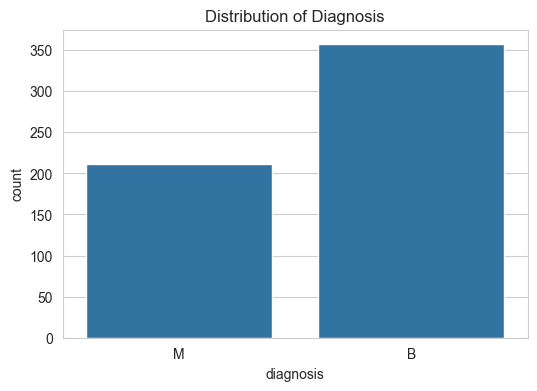

In [9]:
# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title("Distribution of Diagnosis")
plt.show()

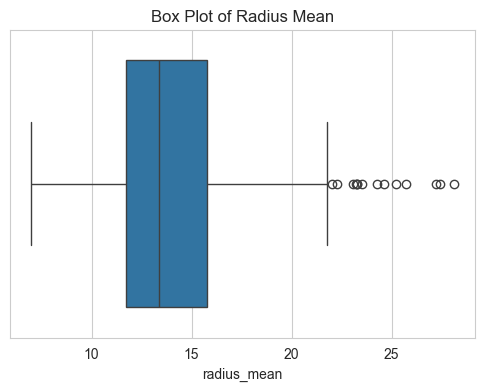

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['radius_mean'])
plt.title("Box Plot of Radius Mean")
plt.show()

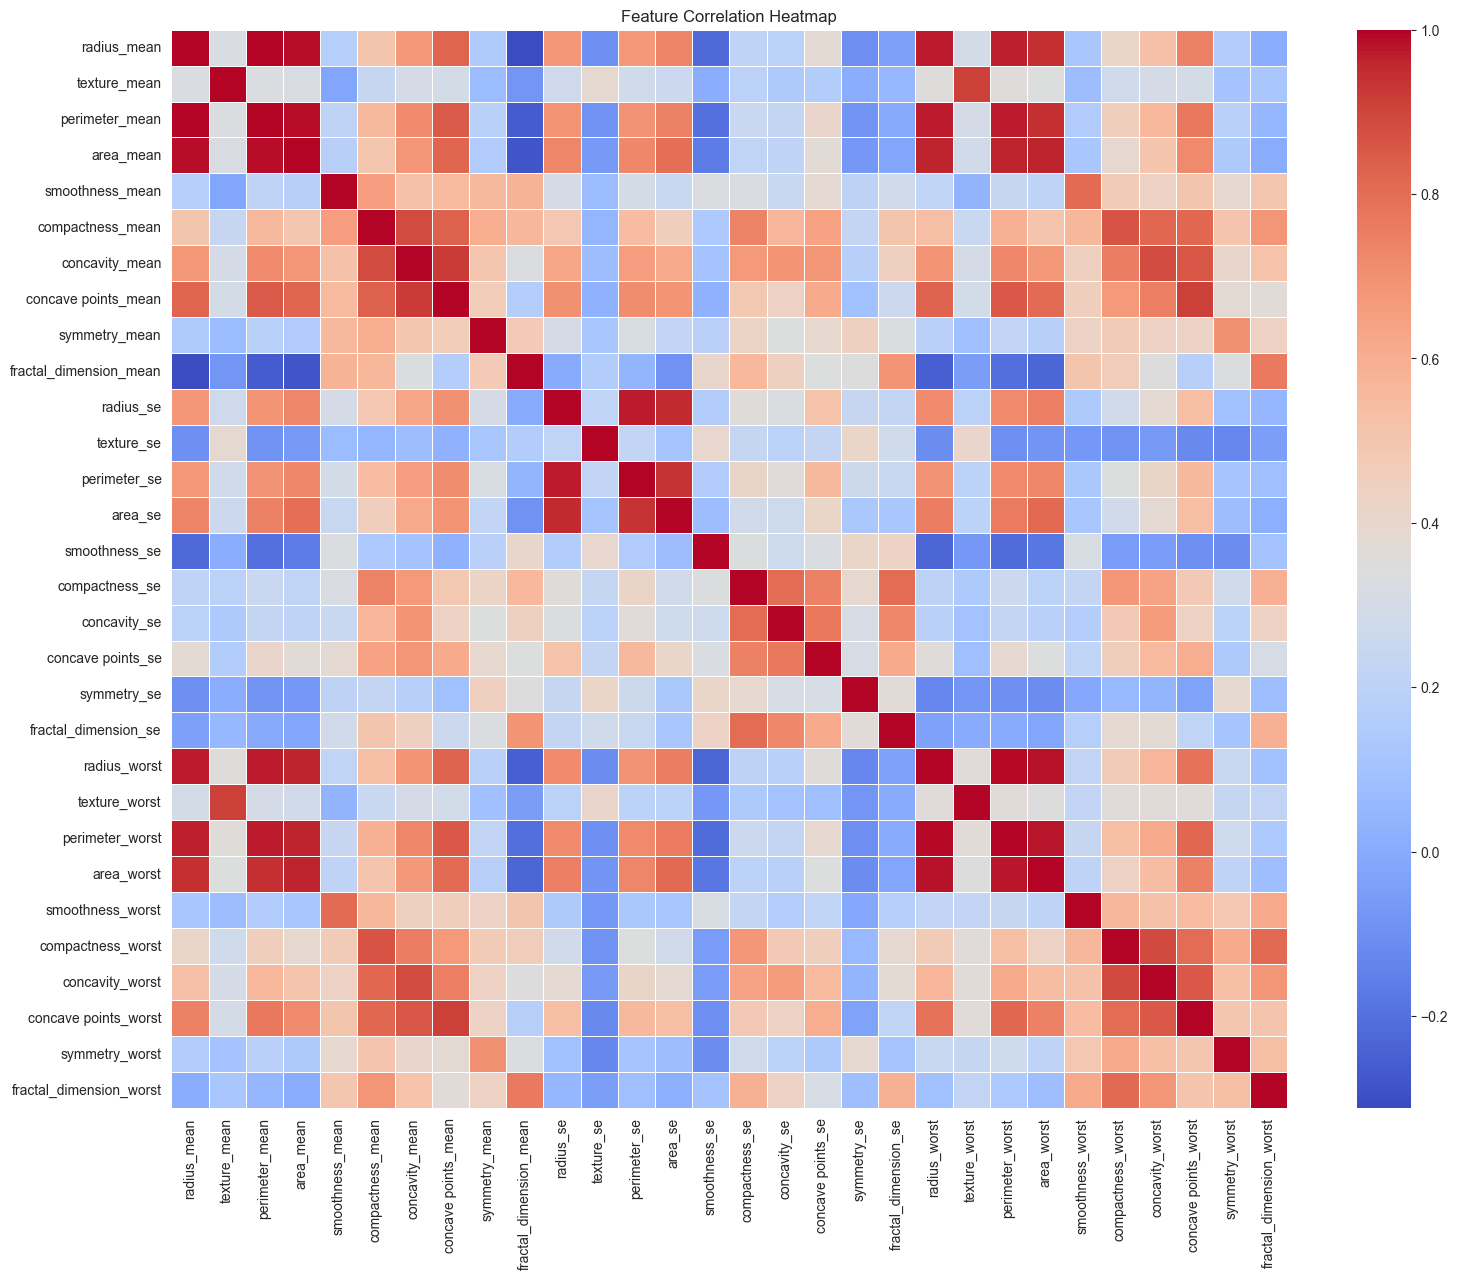

In [10]:
plt.figure(figsize=(18, 14))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
Machine Learning Model

In [ ]:
#Feature Engineering and Data Preparation


In [74]:
# Convert diagnosis column to 0 (benign) and 1 (malignant)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
# Split features and labels
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [ ]:
#Improve the ML Pipeline
#Train-Test Split


In [18]:
# Define models
models = {
   "Logistic Regression": LogisticRegression(
    max_iter=5000,
    random_state=42
),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities (needed for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Sort by ROC-AUC (or Accuracy if you prefer)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973684,0.976190,0.953488,0.964706,0.997380
2,Random Forest,0.964912,0.975610,0.930233,0.952381,0.995251
1,Decision Tree,0.947368,0.930233,0.930233,0.930233,0.943990


In [28]:
# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



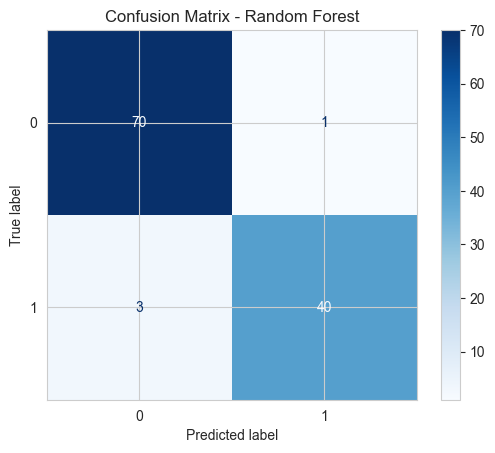

In [29]:
#Confusion Matrix for the Best Model
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

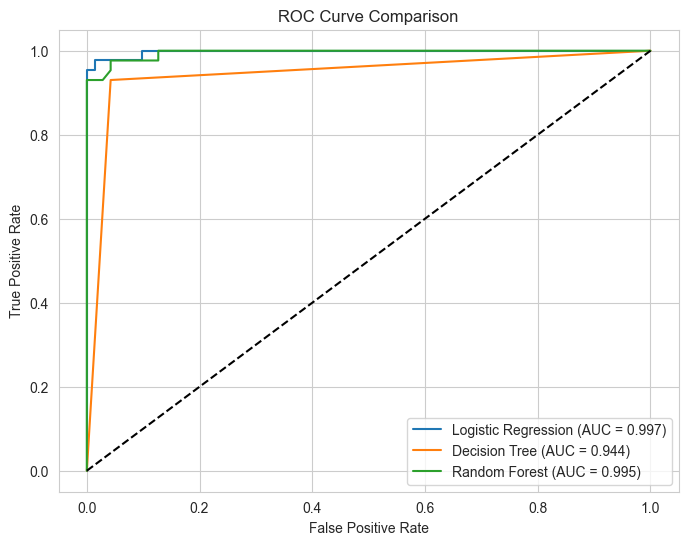

In [21]:
#Plot ROC Curves
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr,
             label=f"{name} (AUC = {auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

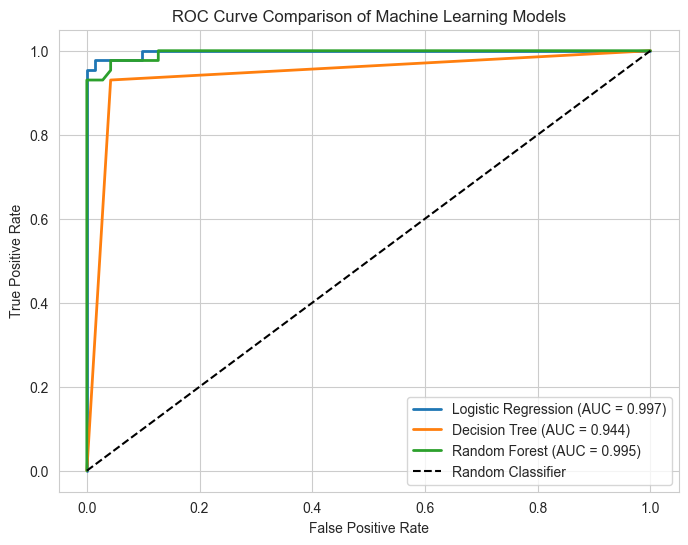

In [25]:
#ROC Curve Comparison
plt.figure(figsize=(8,6))

for name, model in models.items():

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

# Random guessing line
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [ ]:
Hyperparameter Tuning

In [30]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.9626373626373625


In [31]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [60]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Convert back to DataFrames
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)


In [ ]:
#Explainable AI (SHAP & LIME)


In [38]:
#Install SHAP
!pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
#Importing SHAP
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (for notebooks)
shap.initjs()

In [62]:
#Creating the SHAP Explainer
explainer = shap.TreeExplainer(best_model)
# Step 4: Create an Explanation object
shap_values = explainer.shap_values(X_test)

In [63]:
#Select malignant class (class 1)
shap_values_class1 = shap_values[:, :, 1]



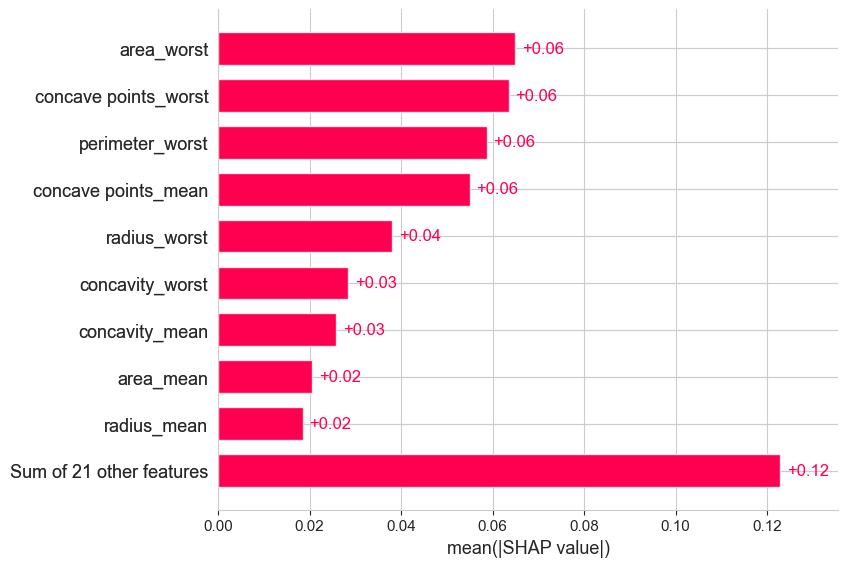

In [64]:
shap_values_class1 = shap_values[:, :, 1]

shap_explanation = shap.Explanation(
    values=shap_values_class1,
    base_values=explainer.expected_value[1],
    data=X_test,
    feature_names=X_test.columns
)

shap.plots.bar(shap_explanation)


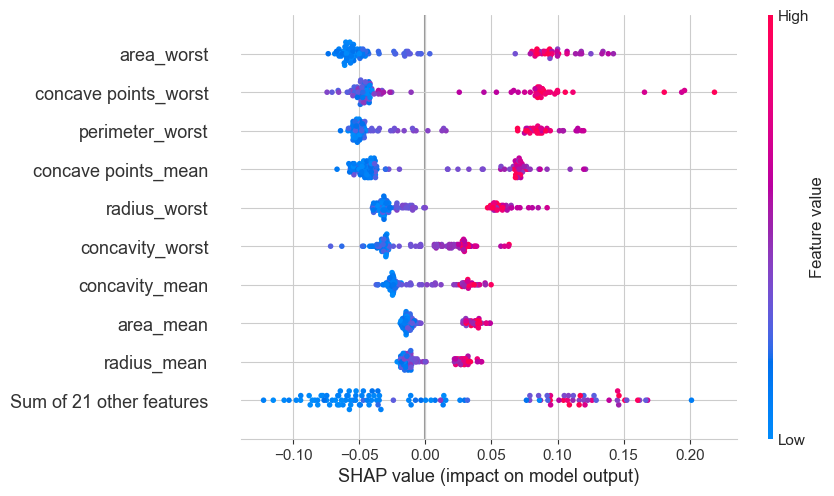

In [52]:
shap.plots.beeswarm(shap_explanation)

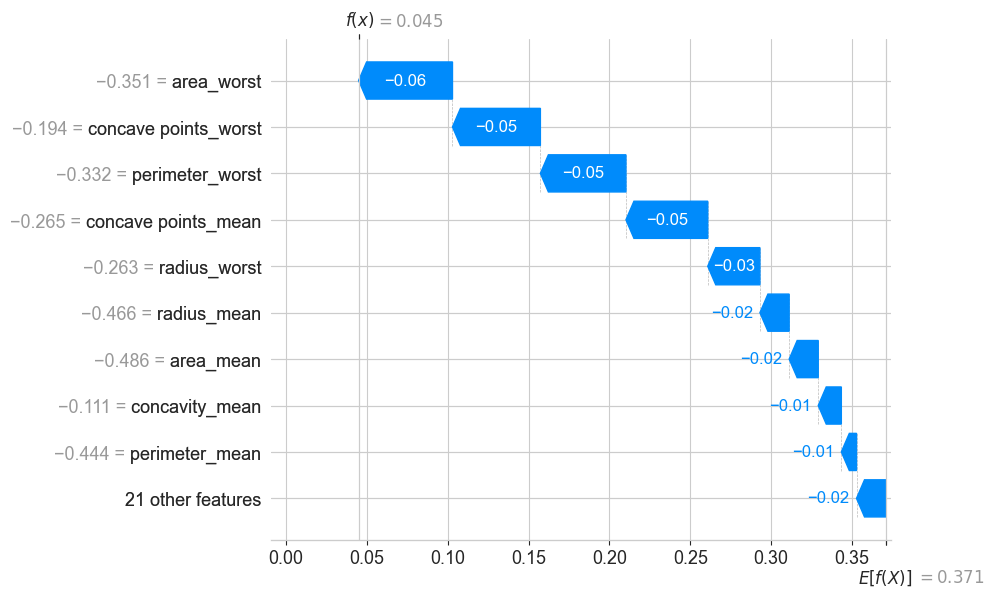

In [65]:
#Local Explanation (Explain One Prediction)
sample_index = 0

single_prediction = shap_explanation[sample_index]

shap.plots.waterfall(single_prediction)

In [77]:
prediction = model.predict(X_test[[sample_index]])
probability = model.predict_proba(X_test[[sample_index]])

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.97 0.03]]


In [79]:
#force plot
shap.plots.force(shap_explanation[sample_index])

In [ ]:
#Install and Import LIME

In [75]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ------- -------------------------------- 2.1/11.9 MB 9.7 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.9 MB 9.8 MB/s eta 0:00:01
   -------------------- ------------------- 6.0/11.9 MB 9.5 MB/s eta 0:00:01
   -------------------------- ------------- 7.9/11.9 MB 9.3 MB/s eta 0:00:01
   --------------------------------- ------ 10.0/11.9 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------  11.8/11.9 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? e


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from lime.lime_tabular import LimeTabularExplainer

In [69]:
#Create LIME Explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['Benign', 'Malignant'],
    mode='classification'
)

NameError: name 'LimeTabularExplainer' is not defined

In [79]:
#Explain One Prediction
sample_index = 0

lime_explanation = explainer_lime.explain_instance(
    X_test.iloc[sample_index].values,
    lambda x: model.predict_proba(pd.DataFrame(x, columns=X_train.columns)),
    num_features=10
)

In [80]:
lime_explanation.show_in_notebook()

In [ ]:
# Conclusion
This project successfully developed a machine learning model to classify breast tumors as benign or malignant using clinical diagnostic features from the Breast Cancer Wisconsin dataset. A complete machine learning workflow was implemented, including data preprocessing, exploratory data analysis, feature engineering, model training, prediction, and performance evaluation.
To enhance transparency and trust in the model's predictions,Explainable AI (XAI)techniques were integrated using SHAP and LIME.
SHAP provided both global and local explanations by identifying the most influential features across the dataset and explaining individual predictions, while LIME offered additional patient-level interpretability.
These techniques demonstrate how machine learning models can move beyond accurate predictions to provide understandable and actionable insights.
Overall, the project highlights the importance of combining predictive performance with model interpretability in healthcare applications. By making AI decisions more transparent, this approach can improve clinician confidence, support informed decision-making, and contribute to the development of trustworthy AI systems for medical diagnosis.
